In [3]:
import torch
%run Foward.ipynb
%run Unet.ipynb
import matplotlib.pyplot as plt

# Load the model and parameters

path = "ddpm_unet_model_final.pth"
model_states = torch.load(path, map_location = device)
model = Unet().to(device)
model.load_state_dict(model_states["model_state_dict"], strict=True)



torch.Size([2, 3, 64, 64])
Testing on device: cuda
Total Trainable Parameters: 87,600,899
Input shape:  torch.Size([2, 3, 64, 64])
Output shape: torch.Size([2, 3, 64, 64])
✅ Shape Test Passed!
✅ Backward Pass & Gradient Flow Test Passed!
PASS test_shape_default_small: torch.Size([2, 3, 32, 32])
PASS test_shape_true_defaults: torch.Size([1, 3, 64, 64])
PASS test_zero_init_output: output is all zeros at init, as expected
PASS test_backward_all_params_get_grad: all params received gradients
PASS test_various_batch_sizes
PASS test_different_level_counts
PASS test_skip_connection_count_matches: 8 produced == 8 consumed
attn=(32,) pattern: [[False, False], [True, True], [True, True], [False, False], [False, False], [True, True], [True, True], [False, False]]
attn=()    pattern: [[False, False], [True, True], [True, True], [False, False], [False, False], [True, True], [True, True], [False, False]]
CONFIRMED BUG: `attn` constructor argument is currently ignored; attention placement is hardcode

<All keys matched successfully>

In [4]:
# DDPM sampling Method

@torch.no_grad()
def sample(model, image_size=64, batch_size=4, channels=3):
    model.eval()
    
    with torch.autocast(device_type="cuda", enabled=False):
        x = torch.randn(batch_size, channels, image_size, image_size, device=device, dtype=torch.float32) 

        for t in reversed(range(0, T)):
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)
            
            predicted_noise = model(x, t_batch).to(torch.float32)
            

            alpha_bar_t = alpha_bar[t]
            beta_t = beta_range[t - 1]          
            alpha_t = 1.0 - beta_t              

            # 1. Estimate clean x_0
            pred_x0 = (x - torch.sqrt(1.0 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
            
            # 2. Dynamic Scaling
            max_val = pred_x0.abs().flatten(1).max(dim=1)[0].view(-1, 1, 1, 1)
            pred_x0 = pred_x0 / torch.clamp(max_val, min=1.0)

            # 3. Compute mean for the next step down
            alpha_bar_t_prev = alpha_bar[t - 1] if t > 1 else torch.tensor(1.0, device=device)
            
            mean = (torch.sqrt(alpha_bar_t_prev) * beta_t / (1.0 - alpha_bar_t)) * pred_x0 + \
                   (torch.sqrt(alpha_t) * (1.0 - alpha_bar_t_prev) / (1.0 - alpha_bar_t)) * x

            if t > 1:
                posterior_variance = ((1.0 - alpha_bar_t_prev) / (1.0 - alpha_bar_t)) * beta_t
                noise = torch.randn_like(x)
                x = mean + torch.sqrt(posterior_variance) * noise
            else:
                # THE FIX: Bypass the mean calculation on the final step. 
                # Output the model's pure, unadulterated prediction of the clean image.
                x = pred_x0  

        x = torch.clamp(x, -1.0, 1.0)
        
    model.train()
    return x

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.025730878..0.97833896].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0128515065..1.0244975].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.021848634..1.042177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07963167..0.97399676].


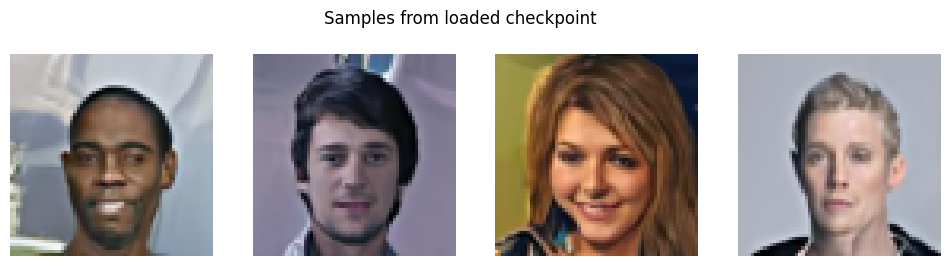

In [7]:
# DDPM sampling

with torch.no_grad():
    samples = sample(model, image_size=64, batch_size=4)

# Print min, max, and mean for each image in the batch
for i in range(samples.shape[0]):
    img = samples[i]
    
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(show_image(samples[i]))
    axes[i].axis("off")
plt.suptitle("Samples from loaded checkpoint")
plt.show()

In [8]:
# DDIM Sampling process

@torch.no_grad()
def sample_ddim(model, image_size=64, batch_size=4, channels=3, num_steps=50, eta=0.0):
    model.eval()
    
    with torch.autocast(device_type="cuda", enabled=False):
        x = torch.randn(batch_size, channels, image_size, image_size, device=device, dtype=torch.float32)

        # Create a skipped timeline (e.g., 50 steps out of T=1000)
        # We step backwards from T-1 down to 0
        step_indices = torch.linspace(T - 1, 0, num_steps, device=device).long()

        for i in range(len(step_indices)):
            t = step_indices[i]
            t_batch = torch.full((batch_size,), t.item(), device=device, dtype=torch.long)
            
            predicted_noise = model(x, t_batch).to(torch.float32)

            alpha_bar_t = alpha_bar[t]
            
            # 1. Estimate clean x_0
            pred_x0 = (x - torch.sqrt(1.0 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
            
            pred_x0 = pred_x0.clamp(-1.0, 1.0)
            # Get previous alpha_bar (handle t=0 case safely)
            if i < len(step_indices) - 1:
                t_prev = step_indices[i + 1]
                alpha_bar_t_prev = alpha_bar[t_prev]
            else:
                alpha_bar_t_prev = torch.tensor(1.0, device=device)

            # 2. DDIM Deterministic/Stochastic Update formula
            # eta = 0.0 means fully deterministic (fastest & sharpest)
            sigma_t = eta * torch.sqrt((1.0 - alpha_bar_t_prev) / (1.0 - alpha_bar_t)) * torch.sqrt(1.0 - alpha_bar_t / alpha_bar_t_prev)
            
            direction_antisens = torch.sqrt(torch.clamp(1.0 - alpha_bar_t_prev - sigma_t**2, min=0.0)) * predicted_noise
            
            # Compute x_{t-1}
            x = torch.sqrt(alpha_bar_t_prev) * pred_x0 + direction_antisens
            
            if eta > 0.0 and i < len(step_indices) - 1:
                x = x + sigma_t * torch.randn_like(x)

        x = torch.clamp(x, -1.0, 1.0)
        
    model.train()
    return x

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05305256..1.0011361].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05135548..1.0278311].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.031113707..1.0575404].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11895196..1.1478564].


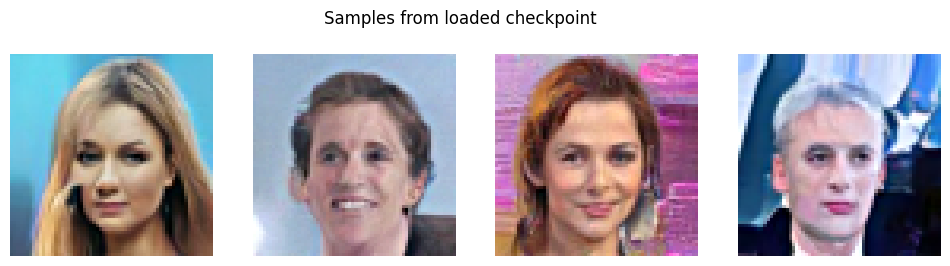

In [10]:
# DDIM sampling

with torch.no_grad():
    samples = sample_ddim(model, image_size=64, batch_size=4, num_steps= 250)

# Print min, max, and mean for each image in the batch
for i in range(samples.shape[0]):
    img = samples[i]
    
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(show_image(samples[i]))
    axes[i].axis("off")
plt.suptitle("Samples from loaded checkpoint")
plt.show()